In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.0,
    random_state=42
)

In [3]:
class KMeansScratch:

    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):

        n_samples = X.shape[0]

        # Randomly initialize centroids
        random_indices = np.random.choice(
            n_samples,
            self.k,
            replace=False
        )

        self.centroids = X[random_indices]

        for _ in range(self.max_iters):

            # Assign clusters
            clusters = self.assign_clusters(X)

            # Store old centroids
            old_centroids = self.centroids.copy()

            # Update centroids
            self.centroids = np.array([
                X[clusters == i].mean(axis=0)
                for i in range(self.k)
            ])

            # Check convergence
            if np.allclose(old_centroids, self.centroids):
                break

        self.labels_ = clusters

    def assign_clusters(self, X):

        distances = np.linalg.norm(
            X[:, np.newaxis] - self.centroids,
            axis=2
        )

        return np.argmin(distances, axis=1)


In [4]:
manual_kmeans = KMeansScratch(k=3)

manual_kmeans.fit(X)

manual_labels = manual_kmeans.labels_

manual_centroids = manual_kmeans.centroids


In [5]:
sklearn_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

sklearn_kmeans.fit(X)

sklearn_labels = sklearn_kmeans.labels_

sklearn_centroids = sklearn_kmeans.cluster_centers_

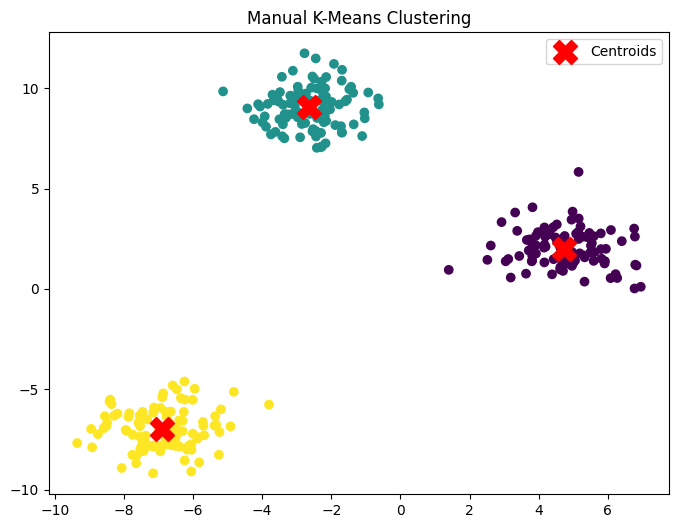

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=manual_labels,
    cmap='viridis'
)

plt.scatter(
    manual_centroids[:,0],
    manual_centroids[:,1],
    marker='X',
    s=300,
    color='red',
    label='Centroids'
)
plt.title("Manual K-Means Clustering")
plt.legend()
plt.show()


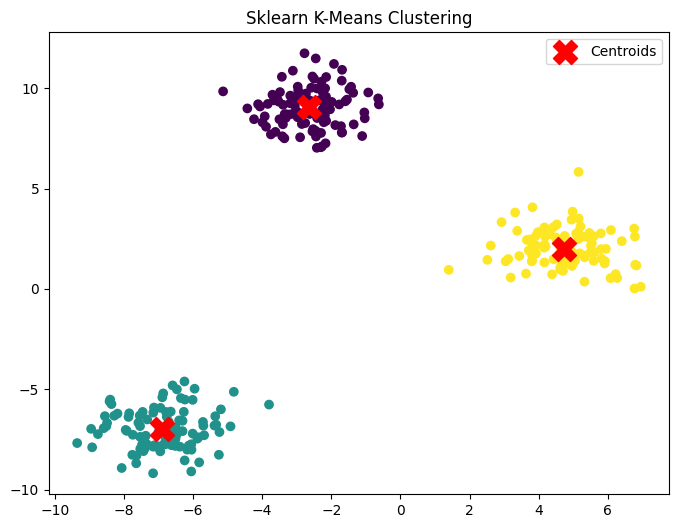

In [7]:

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=sklearn_labels,
    cmap='viridis'
)

plt.scatter(
    sklearn_centroids[:,0],
    sklearn_centroids[:,1],
    marker='X',
    s=300,
    color='red',
    label='Centroids'
)
plt.title("Sklearn K-Means Clustering")
plt.legend()
plt.show()

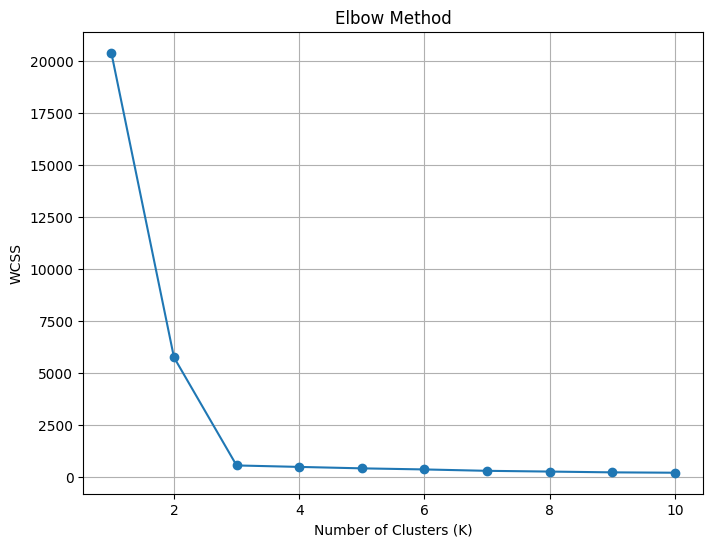

In [8]:
wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,6))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
manual_silhouette = silhouette_score(
    X,
    manual_labels
)

sklearn_silhouette = silhouette_score(
    X,
    sklearn_labels
)

print("\nSilhouette Scores")
print("-" * 30)
print("Manual K-Means :", round(manual_silhouette, 4))
print("Sklearn K-Means:", round(sklearn_silhouette, 4))

In [9]:
print("\nFirst 20 Cluster Assignments")
print("-" * 30)

print("Manual Labels:")
print(manual_labels[:20])

print("\nSklearn Labels:")
print(sklearn_labels[:20])
print("\nManual Centroids")
print(manual_centroids)

print("\nSklearn Centroids")
print(sklearn_centroids)



First 20 Cluster Assignments
------------------------------
Manual Labels:
[2 2 1 0 2 0 1 0 1 1 1 0 1 1 2 1 2 0 1 1]

Sklearn Labels:
[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]

Manual Centroids
[[ 4.74710337  2.01059427]
 [-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]]

Sklearn Centroids
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


In [10]:
import joblib


joblib.dump(sklearn_kmeans, "kmeans_model.pkl")

print("Model saved successfully as kmeans_model.pkl")

Model saved successfully as kmeans_model.pkl


In [11]:
import joblib


loaded_model = joblib.load("kmeans_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [12]:
from google.colab import files

files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>